## Optimal Partitioning for Change Point Detection

In [138]:
import matplotlib.pyplot as plt
import numpy as np

In [139]:
SIGMA=1     # standard deviation to be used in Gaussian Change in Mean
BETA=100    # used to prevent overfitting, i.e. can be used to control the number of change points there will be.

In [140]:
def get_gaussian_change_in_mean(y, sigma, low, up):
    mean = y[low:up+1].mean()
    return ((y[low:up+1] - mean) ** 2).sum() / (sigma ** 2)

In [141]:
def get_change_points(y, sigma, beta):
    cp = []
    F = [-beta]

    for t in range(0, len(y)):
        losses = [F[i] + get_gaussian_change_in_mean(y, sigma, low=i, up=t) + beta for i in range(t + 1)]
        best_loss = min(losses)
        F.append(best_loss)
        t_ = losses.index(best_loss)
        if len(cp) == 0:
            cp_val = [t_]
        else:
            if t_ > 0:
                cp_val = [*cp[t_ - 1], t_]
        cp.append(cp_val)

    return cp

In [142]:
y = np.concat(
    [np.random.randn(30, ) + 5,
    np.random.randn(45, ),
    np.random.randn(30, ) + 10]
)

In [143]:
cps = get_change_points(y, SIGMA, BETA)

In [144]:
cps[-1]

[0, 30, 75]

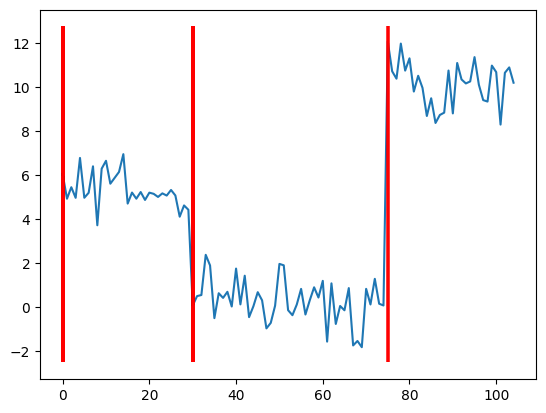

In [145]:
plt.plot(y)
ymin, ymax = plt.ylim()
for cp in cps:
    plt.vlines(x=cp, ymin=ymin, ymax=ymax, color="red")

## References

- https://www.lancaster.ac.uk/~romano/teaching/2425MATH337/3_multiple_changes.html